### Introduction


The goal of this task is to build a machine learning model that can predict medical insurance charges based on various features such as age, BMI, number of children, smoking habits, and region.

This task helps in understanding how different factors influence insurance costs and how predictive models can be used in real-world business problems.

### Import Libraries

In [18]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Observation:

### Load Dataset

In [19]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.listdir('/content/drive/MyDrive')
import pandas as pd

# Dataset download automatically
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

Mounted at /content/drive


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Dataset Shape

In [20]:
import pandas as pd

# Dataset download automatically
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Check number of rows and columns
df.shape

(1338, 7)

### Observation

Dataset contains multiple rows (records) and 7 columns (features).

### Column Names

In [21]:
# Display column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### Observation

Columns include both numerical and categorical data.

### Dataset Information

In [22]:
# Get detailed info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Observation

Numerical: age, bmi, children, charges

Categorical: sex, smoker, region

No null values detected

### Statistical Summary

In [23]:
# Summary statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Observation

Provides mean, min, max, and quartile values for numerical features.

### Missing Values

In [24]:
# Check missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Observation

No missing values found → dataset is clean.

### Data Visualization (Charges Distribution)

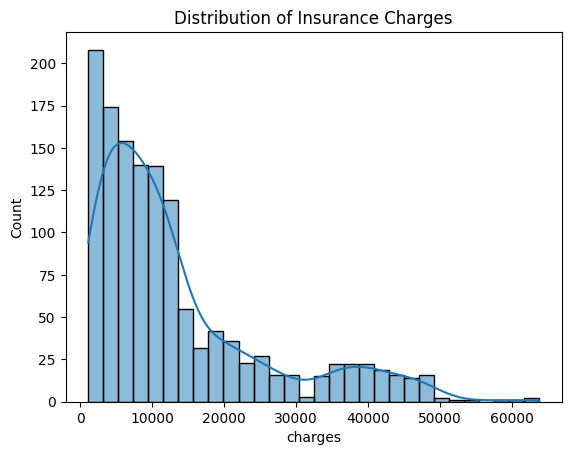

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of charges
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

### Observation

Charges are right-skewed → few people have very high medical costs.

### Smoker vs Charges

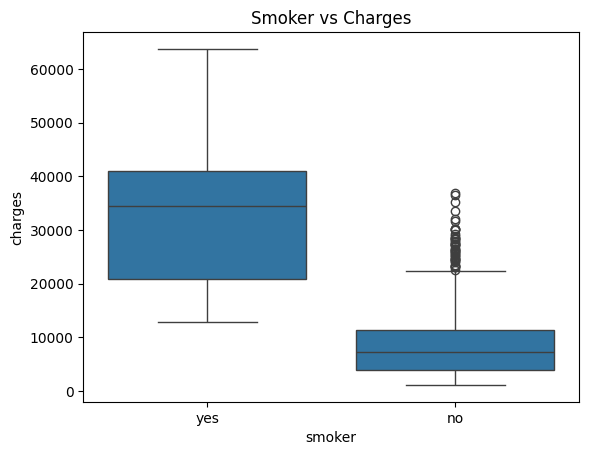

In [26]:
# Boxplot for smoker vs charges
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

### Observation

Smokers have significantly higher insurance charges compared to non-smokers, indicating a strong relationship between smoking and medical expenses.

### Age vs Charges (Scatter Plot)

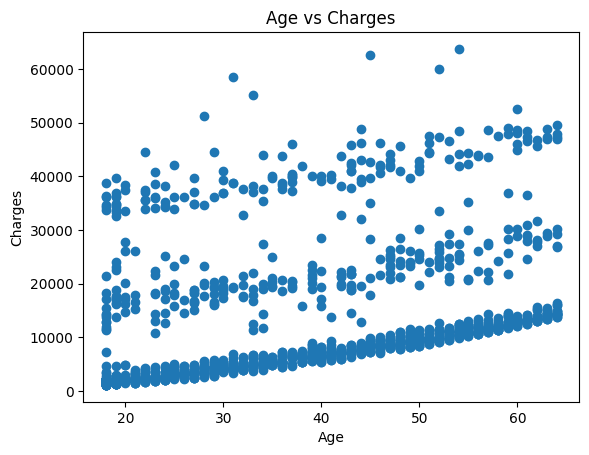

In [35]:
# Age vs Charges
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

### Observation

As age increases, insurance charges generally increase. Older people tend to have higher medical costs.

### BMI vs Charges

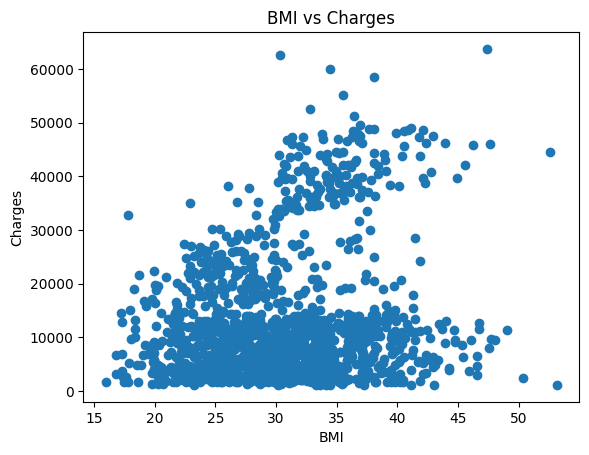

In [36]:
# BMI vs Charges
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

### Observation

Higher BMI is associated with higher insurance charges, indicating obesity impacts medical costs.

### Children vs Charges (Bar Plot)

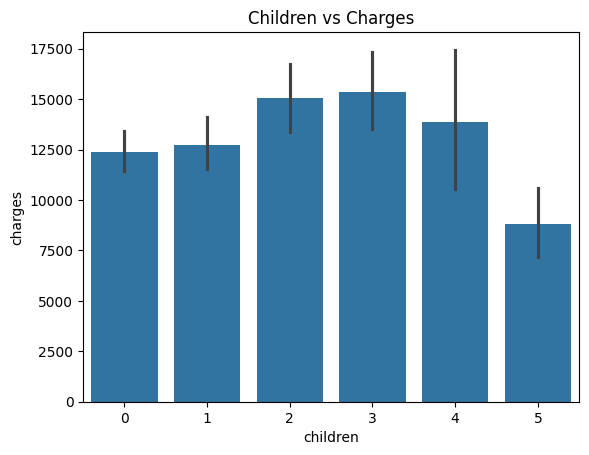

In [37]:
# Children vs Charges
sns.barplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

### Observation

Charges slightly increase with number of children, but impact is not very strong.

### Region vs Charges

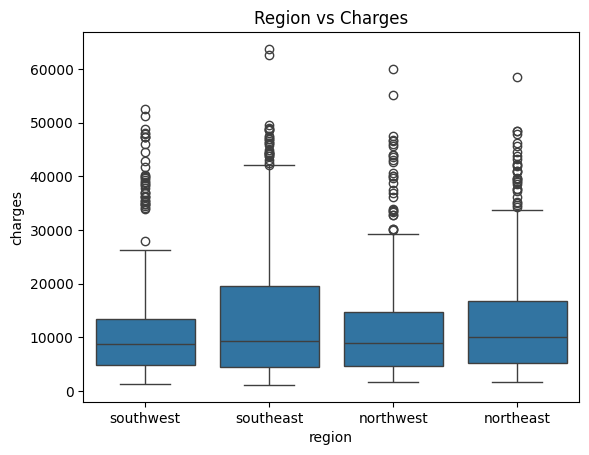

In [38]:
# Region vs Charges
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Charges")
plt.show()

### Observation

Insurance charges vary slightly by region, but no major difference compared to smoking.

### Corelation Heatmap

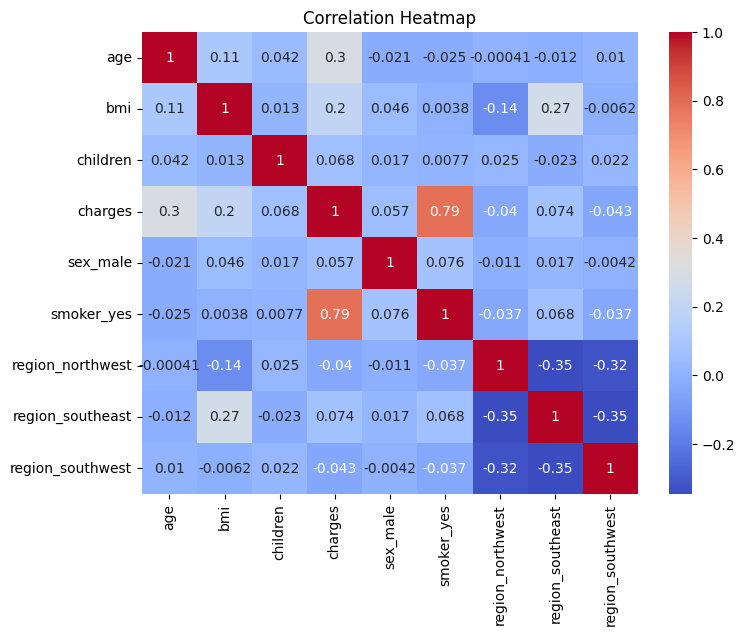

In [39]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

Smoker has the highest correlation with charges

Age and BMI also show positive correlation

Other features have weaker relationships

### Encoding Categorical Data

In [27]:
# Convert categorical variables into numeric
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### Observation

Categorical data converted into numerical format for ML model

### Feature Selection

In [28]:
# Separate features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

### Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Observation

Data split into 80% training and 20% testing.

### Model Building (Linear Regression)

In [30]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

### Observation

Model trained successfully.

### Prediction

In [33]:
# Predict on test data
y_pred = model.predict(X_test)

### Model Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 4181.19447375365
Mean Squared Error: 33596915.85136145


### Observation:

The model shows reasonable performance, but prediction errors indicate that more advanced models could further improve accuracy.

MAE shows average prediction error

MSE penalizes large errors

Lower values = better model

### Conclusion

This project successfully demonstrated how machine learning can be used to predict medical insurance charges based on individual characteristics such as age, BMI, smoking habits, number of children, and region.

Through exploratory data analysis and visualization, it was observed that smoking is the most significant factor affecting insurance charges, with smokers having substantially higher costs compared to non-smokers. Additionally, age and BMI also showed a positive relationship with insurance expenses, indicating that older individuals and those with higher body mass index tend to incur greater medical costs.

The dataset was clean and required minimal preprocessing, making it suitable for model building. A Linear Regression model was applied, which provided a reasonable baseline for predicting insurance charges.

Overall, this task highlights the importance of data analysis and predictive modeling in real-world applications. Such models can assist insurance companies in pricing strategies, risk assessment, and decision-making, ultimately improving efficiency and accuracy.

"Future work may include using advanced models like Random Forest for improved accuracy."

###